# Global Findex 2025 — Mobile Money Gap, Full-Scale Income-Adjustment Test

**Source:** World Bank Global Findex Database 2025 (2024 survey wave), 
`GlobalFindexDatabase2025.csv`. Full country panel — not the small hand-picked 
peer list from the pilot.

**Purpose:** Test whether the "banked but not digitally-banked" gap (traditional 
account ownership vs. mobile-money account ownership) is a genuine Nepal-specific 
constraint, or income-typical — same method already validated on governance, 
compute, and research findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FINDEX_FILE = RAW_DIR / "GlobalFindexDatabase2025.csv"
GDP_FILE = next(RAW_DIR.glob("API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))
GDP_META_FILE = next(RAW_DIR.glob("Metadata_Country_API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
sns.set_style("whitegrid")
NEPAL = "Nepal"

## 1. Load Findex national totals (2024 wave, `group == 'all'`) and merge with GDP

In [2]:
findex = pd.read_csv(FINDEX_FILE, low_memory=False)
latest = findex[(findex.year == 2024) & (findex.group == "all") & (findex.group2 == "all")].copy()

KEY_COLS = ["countrynewwb", "codewb", "account_t_d", "mobileaccount_t_d", "fiaccount_t_d", "borrow_any_t_d"]
latest = latest[KEY_COLS].dropna(subset=["account_t_d", "mobileaccount_t_d"])
latest["gap"] = latest["account_t_d"] - latest["mobileaccount_t_d"]

wb = pd.read_csv(GDP_FILE, skiprows=4)
wb_meta = pd.read_csv(GDP_META_FILE)
real_codes = set(wb_meta.loc[wb_meta["Region"].notna(), "Country Code"])
wb = wb[wb["Country Code"].isin(real_codes)]
year_cols = [c for c in wb.columns if c.isdigit()]

def latest_value(row):
    for y in sorted(year_cols, reverse=True):
        if pd.notna(row[y]):
            return row[y]
    return np.nan

wb["gdp"] = wb.apply(latest_value, axis=1)
wb_clean = wb[["Country Code", "gdp"]].dropna()

merged = latest.merge(wb_clean, left_on="codewb", right_on="Country Code", how="left")
merged["log_gdp"] = np.log(merged["gdp"])
merged = merged.dropna(subset=["log_gdp"])

print(f"Matched {len(merged)} countries with GDP data")
merged[merged.countrynewwb == NEPAL]

Matched 81 countries with GDP data


,countrynewwb,codewb,account_t_d,mobileaccount_t_d,fiaccount_t_d,borrow_any_t_d,gap,Country Code,gdp,log_gdp
52,Nepal,NPL,0.599911,0.105834,0.575257,0.704009,0.494077,NPL,6175.158972,8.72829


## 2. Income-adjustment test — is Nepal's mobile-money gap unusual, or income-typical?

In [3]:
def income_adjust(df, col, country=NEPAL):
    sub = df.dropna(subset=[col]).copy()
    slope, intercept, r, p, se = stats.linregress(sub["log_gdp"], sub[col])
    sub["resid"] = sub[col] - (slope * sub["log_gdp"] + intercept)
    nepal_resid = sub.loc[sub.countrynewwb == country, "resid"]
    if len(nepal_resid) == 0:
        return None
    nepal_resid = nepal_resid.iloc[0]
    pct = stats.percentileofscore(sub["resid"], nepal_resid)
    return {"r": r, "p": p, "n": len(sub), "nepal_residual": nepal_resid, "nepal_percentile": pct}, sub

results = {}
for col, label in [("account_t_d", "Traditional Account Ownership"),
                    ("mobileaccount_t_d", "Mobile Money Account Ownership"),
                    ("gap", "Account-minus-Mobile Gap")]:
    res, sub = income_adjust(merged, col)
    results[label] = res
    print(f"{label:32s} r={res['r']:.3f} p={res['p']:.4f} n={res['n']:3d} | "
          f"Nepal residual={res['nepal_residual']:+.2f} (percentile {res['nepal_percentile']:.1f})")

pd.DataFrame(results).T.to_csv(PROCESSED_DIR / "findex_income_adjusted_results.csv")

Traditional Account Ownership    r=0.578 p=0.0000 n= 81 | Nepal residual=+0.07 (percentile 65.4)
Mobile Money Account Ownership   r=-0.018 p=0.8729 n= 81 | Nepal residual=-0.22 (percentile 16.0)
Account-minus-Mobile Gap         r=0.602 p=0.0000 n= 81 | Nepal residual=+0.29 (percentile 95.1)


## 3. Regional comparison table — South Asia, mobile-money gap

In [4]:
SOUTH_ASIA = ["Nepal", "India", "Pakistan", "Bangladesh", "Sri Lanka", "Bhutan", "Afghanistan", "Maldives"]
sa = merged[merged.countrynewwb.isin(SOUTH_ASIA)][
    ["countrynewwb", "gdp", "account_t_d", "mobileaccount_t_d", "gap"]
].sort_values("gap", ascending=False).reset_index(drop=True)

sa.to_csv(PROCESSED_DIR / "south_asia_findex_gap.csv", index=False)
with open(PROCESSED_DIR / "south_asia_findex_gap.md", "w") as f:
    f.write(sa.to_markdown(index=False))
sa

,countrynewwb,gdp,account_t_d,mobileaccount_t_d,gap
0,Sri Lanka,17065.029864,0.816921,0.029962,0.786960
1,India,11747.916044,0.890248,0.231008,0.659241
2,Nepal,6175.158972,0.599911,0.105834,0.494077
3,Bangladesh,10153.708379,0.432840,0.207684,0.225156
4,Pakistan,6573.416134,0.272960,0.183579,0.089381


## 4. Figure — dumbbell chart, traditional vs. mobile account ownership

The gap itself as the visual object — different chart type from anything used 
so far in this project.

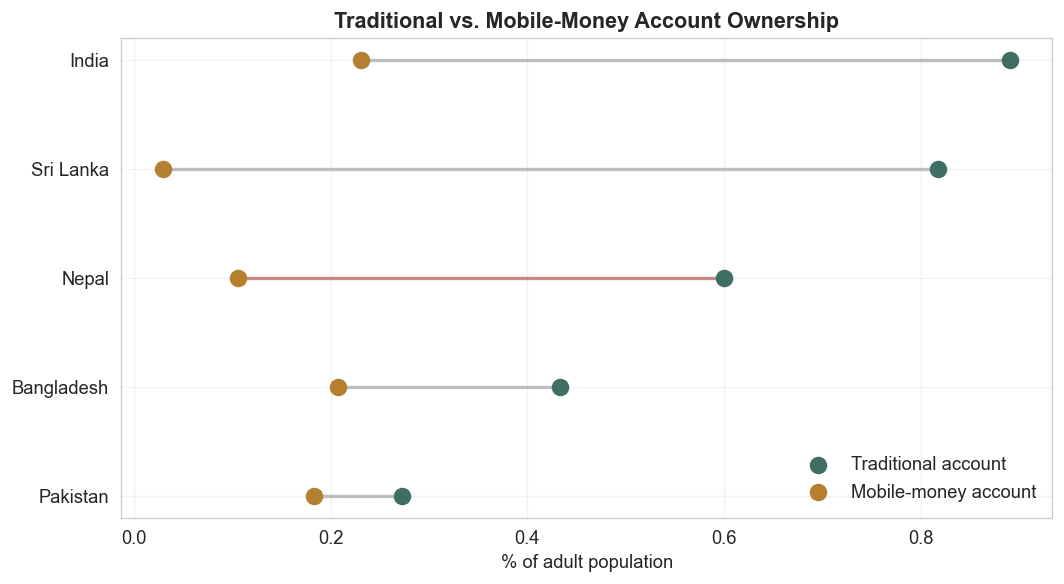

In [5]:
plot_countries = SOUTH_ASIA + ["China", "United States"]
pd_ = merged[merged.countrynewwb.isin(plot_countries)].sort_values("account_t_d")

fig, ax = plt.subplots(figsize=(9, max(5, 0.5*len(pd_))))
y = np.arange(len(pd_))

for i, (_, row) in enumerate(pd_.iterrows()):
    color = "#A6423A" if row.countrynewwb == NEPAL else "#999999"
    ax.plot([row.mobileaccount_t_d, row.account_t_d], [i, i], color=color, linewidth=2, alpha=0.6, zorder=1)
    ax.scatter(row.account_t_d, i, color="#3E6E64", s=90, zorder=3, label="Traditional account" if i==0 else "")
    ax.scatter(row.mobileaccount_t_d, i, color="#B4802F", s=90, zorder=3, label="Mobile-money account" if i==0 else "")

ax.set_yticks(y)
ax.set_yticklabels(pd_.countrynewwb)
ax.set_xlabel("% of adult population")
ax.set_title("Traditional vs. Mobile-Money Account Ownership")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "findex_dumbbell_mobile_gap.png", bbox_inches="tight")
plt.show()